<a href="https://colab.research.google.com/github/goktuggokmen/Graduation-Thesis-Automated-Fish-Species-Recognition-via-ResNet-50-Architecture/blob/main/Recognition%20Model%20Load.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install wget
!pip install --upgrade opencv-python

Looking in indexes: https://pypi.org/simple, https://us-python.pkg.dev/colab-wheels/public/simple/
Looking in indexes: https://pypi.org/simple, https://us-python.pkg.dev/colab-wheels/public/simple/


In [ ]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Lambda, Dense, Flatten
from tensorflow.keras.preprocessing import image
from tensorflow.keras.applications.resnet50 import ResNet50, preprocess_input
from keras.models import load_model

import requests, io, cv2
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt

import warnings
warnings.filterwarnings("ignore")

In [ ]:
IMAGE_SIZE = [200, 200]
dataset = '/content/drive/MyDrive/Species/Training_Set'

In [ ]:
model = load_model('/content/drive/MyDrive/fish.h5')

In [ ]:
test_gen = ImageDataGenerator(
  preprocessing_function=preprocess_input
)

In [ ]:
labels = list(test_gen.flow_from_directory(dataset).class_indices.keys())
labels

Found 34005 images belonging to 20 classes.


['Anthias anthias',
 'Atherinomorus lacunosus',
 'Belone belone',
 'Boops boops',
 'Chlorophthalmus agassizi',
 'Coris julis',
 'Dasyatis centroura',
 'Epinephelus caninus',
 'Gobius niger',
 'Mugil cephalus',
 'Phycis phycis',
 'Polyprion americanus',
 'Pseudocaranx dentex',
 'Rhinobatos cemiculus',
 'Scomber japonicus',
 'Solea solea',
 'Squalus acanthias',
 'Tetrapturus belone',
 'Trachinus draco',
 'Trigloporus lastoviza']

In [ ]:
print("Turunu ogrenmek istediginiz baligin goruntusunu URL olarak giriniz:")
input_img = input()

Turunu ogrenmek istediginiz baligin goruntusunu URL olarak giriniz:
https://i.ytimg.com/vi/CW6TBjBXI_0/maxresdefault.jpg


Goruntudeki Baligin Sinifi : Epinephelus caninus


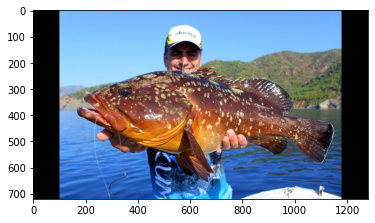

In [ ]:
URL = input_img
response = requests.get(URL)
bytes_img = io.BytesIO(response.content) # veriler bir bellek ici arabellekte byte olarak tutulur.
cv_img = cv2.cvtColor(np.array(Image.open(bytes_img)), cv2.COLOR_RGB2BGR)

internal_image = cv2.resize(cv_img,IMAGE_SIZE)
internal_image = internal_image.reshape(1,IMAGE_SIZE[0], IMAGE_SIZE[1],3)

plt.imshow(Image.open(bytes_img))

p = model.predict(internal_image)
p = np.argmax(p)

print("Goruntudeki Baligin Sinifi :", labels[p])